# Debug one AudioGoal val sample

Set `SAMPLE_INDEX`, build the same `AudioGoalDataset` used by `audiogoal_trainer.py`, run one forward pass, and inspect the prediction/GT before running full-val metrics.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import torch
from tqdm.auto import tqdm

os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba_cache")


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for pth in [start, *start.parents]:
        if (pth / "ss_baselines").exists() and (pth / "configs").exists():
            return pth
    raise RuntimeError(f"Cannot find repo root from {start}")


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

from soundspaces.utils import load_metadata
from soundspaces.mp3d_utils import SCENE_SPLITS
from ss_baselines.savi.config.default import get_config
from ss_baselines.savi.pretraining_ours.audiogoal_dataset import AudioGoalDataset
from ss_baselines.savi.pretraining_ours.audiogoal_predictor import AudioGoalPredictor

DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
CONFIG_PATH = "ss_baselines/savi/config/semantic_audionav/savi.yaml"
SPLIT = "val"
CKPT_PATH = "/home/Disk/yyz/sound-spaces/data/models/savi_final_depth_ipd/ckpt.46.pth"

SAMPLE_INDEX = 0
TOPK = 10
SEED = 0  # controls the random 1-second source-audio crop inside compute_audiogoal

PREDICT_LABEL = False
PREDICT_LOCATION = True

print(f"repo root: {REPO_ROOT}")
print(f"device: {DEVICE}")
print(f"ckpt: {CKPT_PATH}")
print(f"sample index: {SAMPLE_INDEX}")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
2026-06-24 15:13:31.978180: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-24 15:13:32.013994: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-24 15:13:32.65

repo root: /home/Disk/yyz/sound-spaces
device: cuda:1
ckpt: /home/Disk/yyz/sound-spaces/data/models/savi_final_depth_ipd/ckpt.46.pth
sample index: 0


In [2]:
def build_dataset():
    config = get_config(config_paths=CONFIG_PATH, opts=None, run_type=None)
    meta_dir = config.TASK_CONFIG.SIMULATOR.AUDIO.METADATA_DIR
    scenes = SCENE_SPLITS[SPLIT]

    scene_graphs = {}
    for scene in tqdm(scenes, desc="Load scene graphs"):
        _, graph = load_metadata(os.path.join(meta_dir, "mp3d", scene))
        scene_graphs[scene] = graph

    dataset = AudioGoalDataset(
        scene_graphs=scene_graphs,
        scenes=scenes,
        split=SPLIT,
        use_polar_coordinates=True,
        use_cache=False,
    )
    print(f"{SPLIT.upper()} has {len(dataset)} samples")
    return dataset


def load_model():
    if not os.path.exists(CKPT_PATH):
        raise FileNotFoundError(CKPT_PATH)

    model = AudioGoalPredictor(
        predict_label=PREDICT_LABEL,
        predict_location=PREDICT_LOCATION,
    ).to(device=DEVICE)

    ckpt = torch.load(CKPT_PATH, map_location="cpu")
    state_dict = ckpt["audiogoal_predictor"] if "audiogoal_predictor" in ckpt else ckpt
    model.load_state_dict(state_dict, strict=True)
    model.eval()
    print(f"[INFO] loaded ckpt: {CKPT_PATH}")
    return model


def circular_angle_error_deg(pred_deg, gt_deg):
    return abs((float(pred_deg) - float(gt_deg) + 180.0) % 360.0 - 180.0)


def topk_bins(values, k=10):
    values = np.asarray(values)
    idx = np.argsort(values)[-k:][::-1]
    return [(int(i), float(values[i])) for i in idx]


In [3]:
dataset = build_dataset()
model = load_model()


Load scene graphs:   0%|          | 0/11 [00:00<?, ?it/s]

[AudioGoalDataset] Load cache: /home/Disk/yyz/sound-spaces/cache/mp3d_val_pairs25000_polar1.npz
VAL has 42452 samples
[INFO] loaded ckpt: /home/Disk/yyz/sound-spaces/data/models/savi_final_depth_ipd/ckpt.46.pth


In [4]:
# Re-run this cell after changing SAMPLE_INDEX above.

SAMPLE_INDEX = 75

if not (0 <= SAMPLE_INDEX < len(dataset)):
    raise IndexError(f"SAMPLE_INDEX={SAMPLE_INDEX} out of range [0, {len(dataset)})")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

inputs, gts = dataset[SAMPLE_INDEX]
spectrogram, depth = inputs
theta_gt, dist_gt = gts

# Metadata from the lightweight cache/files list.
rir_file, sound_file = dataset.files[SAMPLE_INDEX]
goal = dataset.goals[SAMPLE_INDEX]
scene, agent_angle, receiver_node, source_node = dataset._parse_rir_path(rir_file)
goal_np = goal.detach().cpu().numpy() if torch.is_tensor(goal) else np.asarray(goal)

spec_batch = spectrogram.unsqueeze(0).to(device=DEVICE, dtype=torch.float32)
depth_batch = depth.unsqueeze(0).to(device=DEVICE, dtype=torch.float32)

with torch.inference_mode():
    pred_doa, pred_dist = model({"spectrogram": spec_batch, "depth": depth_batch})

pred_doa_np = pred_doa.squeeze(0).detach().cpu().numpy()
pred_dist_np = pred_dist.squeeze(0).detach().cpu().numpy()
theta_gt_np = theta_gt.detach().cpu().numpy()
dist_gt_np = dist_gt.detach().cpu().numpy()

pred_deg = int(np.argmax(pred_doa_np))
gt_deg = int(np.argmax(theta_gt_np))
angle_err = circular_angle_error_deg(pred_deg, gt_deg)

pred_dist_bin = int(np.argmax(pred_dist_np))
gt_dist_bin = int(np.argmax(dist_gt_np))

print("========== SAMPLE INFO ==========")
print(f"index          : {SAMPLE_INDEX}")
print(f"rir_file       : {rir_file}")
print(f"sound_file     : {sound_file}")
print(f"scene          : {scene}")
print(f"agent_angle    : {agent_angle}")
print(f"receiver_node  : {receiver_node}")
print(f"source_node    : {source_node}")
print(f"raw goal       : {goal_np}")
print(f"spectrogram    : shape={tuple(spectrogram.shape)}, min={spectrogram.min().item():.6f}, max={spectrogram.max().item():.6f}")
print(f"depth          : shape={tuple(depth.shape)}, min={depth.min().item():.6f}, max={depth.max().item():.6f}")

print("\n========== DOA ==========")
print(f"pred_deg       : {pred_deg}")
print(f"gt_deg         : {gt_deg}")
print(f"angle_err      : {angle_err:.4f} deg")
print(f"top-{TOPK} pred DOA : {topk_bins(pred_doa_np, TOPK)}")
print(f"top-{TOPK} gt DOA   : {topk_bins(theta_gt_np, TOPK)}")

print("\n========== DISTANCE ==========")
print(f"pred_dist_bin  : {pred_dist_bin}")
print(f"gt_dist_bin    : {gt_dist_bin}")
print(f"top-{TOPK} pred dist: {topk_bins(pred_dist_np, TOPK)}")
print(f"top-{TOPK} gt dist  : {topk_bins(dist_gt_np, TOPK)}")


========== SAMPLE INFO ==========
index          : 75
rir_file       : data/binaural_rirs/mp3d/x8F5xyUWy9e/0/100_83.wav
sound_file     : counter.wav
scene          : x8F5xyUWy9e
agent_angle    : 0
receiver_node  : 100
source_node    : 83
raw goal       : [16.         3.1415927  1.       ]
spectrogram    : shape=(257, 101, 2), min=-1.000000, max=1.000000
depth          : shape=(1, 128, 128), min=0.000000, max=1.000000

========== DOA ==========
pred_deg       : 180
gt_deg         : 180
angle_err      : 0.0000 deg
top-10 pred DOA : [(180, 0.9965135455131531), (179, 0.9684826135635376), (181, 0.9683623313903809), (182, 0.7153202891349792), (178, 0.7125625014305115), (183, 0.4979739487171173), (177, 0.49296408891677856), (184, 0.34119290113449097), (176, 0.33821213245391846), (175, 0.23063068091869354)]
top-10 gt DOA   : [(180, 0.9999999624005771), (181, 0.8007391578588251), (179, 0.8007355926512848), (182, 0.41111411051047725), (178, 0.4111104496332663), (183, 0.13533618571934616), (177, 

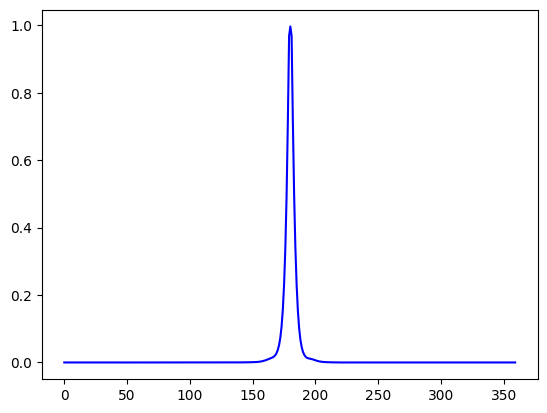

In [5]:
import matplotlib.pyplot as plt
plt.plot(pred_doa_np, label="predicted DOA", color="blue")

## Full val metrics

Run this section after the single-sample debug looks correct. It evaluates all val samples with the same model/dataset settings and reports trainer-style exact accuracies plus angle-error metrics.

In [6]:
from torch.utils.data import DataLoader
import torch.nn as nn

FULL_BATCH_SIZE = 1024
FULL_NUM_WORKERS = 8
FULL_SHUFFLE = False
FULL_MAX_BATCHES = None  # set to e.g. 20 for quick testing

full_loader = DataLoader(
    dataset=dataset,
    batch_size=FULL_BATCH_SIZE,
    shuffle=FULL_SHUFFLE,
    pin_memory=torch.cuda.is_available(),
    num_workers=FULL_NUM_WORKERS,
    sampler=None,
)

regressor_criterion = nn.MSELoss().to(device=DEVICE)
classifier_criterion = nn.CrossEntropyLoss().to(device=DEVICE)

print(f"full val batches: {len(full_loader)}, batch_size={FULL_BATCH_SIZE}")


full val batches: 42, batch_size=1024


In [7]:
running_total_loss = 0.0
running_regressor_loss = 0.0
running_classifier_loss = 0.0
running_regressor_corrects = 0
running_classifier_corrects = 0

all_pred_doa = []
all_gt_doa = []
all_pred_dist = []
all_gt_dist = []

model.eval()
with torch.inference_mode():
    for i, data in enumerate(tqdm(full_loader, desc="Eval full val")):
        if FULL_MAX_BATCHES is not None and i >= FULL_MAX_BATCHES:
            break

        inputs, gts = data
        spectrogram, depth = inputs
        spectrogram = spectrogram.to(device=DEVICE, dtype=torch.float)
        depth = depth.to(device=DEVICE, dtype=torch.float)
        inputs = [spectrogram, depth]

        theta_gt, dist_gt = gts
        theta_gt = theta_gt.to(device=DEVICE, dtype=torch.float)
        dist_gt = dist_gt.to(device=DEVICE, dtype=torch.float)

        predicts_doa, predicts_dis = model({input_type: x for input_type, x in zip(["spectrogram", "depth"], inputs)})

        regressor_loss = regressor_criterion(predicts_doa, theta_gt) + 0.2 * regressor_criterion(predicts_dis, dist_gt)
        classifier_loss = torch.tensor([0], device=DEVICE)
        loss = classifier_loss + regressor_loss

        batch_size = theta_gt.size(0)
        running_total_loss += loss.item() * batch_size
        running_classifier_loss += classifier_loss.item() * batch_size
        running_regressor_loss += regressor_loss.item() * batch_size

        pred_doa = predicts_doa.cpu().detach().numpy()
        pred_doa = np.argmax(pred_doa, -1)
        pred_doa = np.round(pred_doa)

        pred_dis = predicts_dis.cpu().detach().numpy()
        pred_dis = np.argmax(pred_dis, -1)
        pred_dis = np.round(pred_dis)

        gt_doa = theta_gt.cpu().detach().numpy()
        gt_doa = np.argmax(gt_doa, -1)
        gt_doa = np.round(gt_doa)

        gt_dis = dist_gt.cpu().detach().numpy()
        gt_dis = np.argmax(gt_dis, -1)
        gt_dis = np.round(gt_dis)

        running_regressor_corrects += np.sum(gt_doa == pred_doa)
        running_classifier_corrects += np.sum(gt_dis == pred_dis)

        all_pred_doa.append(pred_doa)
        all_gt_doa.append(gt_doa)
        all_pred_dist.append(pred_dis)
        all_gt_dist.append(gt_dis)

full_pred_doa = np.concatenate(all_pred_doa).astype(np.int64)
full_gt_doa = np.concatenate(all_gt_doa).astype(np.int64)
full_pred_dist = np.concatenate(all_pred_dist).astype(np.int64)
full_gt_dist = np.concatenate(all_gt_dist).astype(np.int64)
full_num_eval = len(full_gt_doa)
full_angle_errors = np.array([circular_angle_error_deg(p, g) for p, g in zip(full_pred_doa, full_gt_doa)])

full_total_loss = running_total_loss / full_num_eval
full_regressor_loss = running_regressor_loss / full_num_eval
full_classifier_loss = running_classifier_loss / full_num_eval
full_doa_exact_acc = running_regressor_corrects / full_num_eval
full_dist_exact_acc = running_classifier_corrects / full_num_eval

print("========== FULL VAL TRAINER-STYLE =========={}".format(""))
print(f"samples evaluated    : {full_num_eval}")
print(f"total loss           : {full_total_loss:.6f}")
print(f"label/classifier loss: {full_classifier_loss:.6f}")
print(f"xy/regressor loss    : {full_regressor_loss:.6f}")
print(f"label/dist acc       : {full_dist_exact_acc:.6f}")
print(f"xy/doa exact acc     : {full_doa_exact_acc:.6f}")

print("\n========== FULL VAL ANGLE METRICS =========={}".format(""))
print(f"mean angle error     : {full_angle_errors.mean():.4f} deg")
print(f"median angle error   : {np.median(full_angle_errors):.4f} deg")
print(f"acc <= 5 deg         : {(full_angle_errors <= 5).mean():.6f}")
print(f"acc <= 10 deg        : {(full_angle_errors <= 10).mean():.6f}")
print(f"acc <= 15 deg        : {(full_angle_errors <= 15).mean():.6f}")


Eval full val:   0%|          | 0/42 [00:00<?, ?it/s]

========== FULL VAL TRAINER-STYLE ==========
samples evaluated    : 42452
total loss           : 0.035409
label/classifier loss: 0.000000
xy/regressor loss    : 0.035409
label/dist acc       : 0.097216
xy/doa exact acc     : 0.287902

========== FULL VAL ANGLE METRICS ==========
mean angle error     : 25.3845 deg
median angle error   : 4.0000 deg
acc <= 5 deg         : 0.539315
acc <= 10 deg        : 0.613069
acc <= 15 deg        : 0.656271


In [ ]:
python ss_baselines/av_wan/run.py \
  --run-type eval \
  --exp-config ss_baselines/av_wan/config/semantic_audionav/mp3d/rgbd_ddppo.yaml \
  --model-dir data/models/mp3d/audiogoal_depth \
  EVAL_CKPT_PATH_DIR /home/Disk/sound-space/data/pretrained_weights/audionav/av_wan/mp3d/heard.pth \
  TASK_CONFIG.SIMULATOR.AUDIO.HAS_DISTRACTOR_SOUND False \
  TASK_CONFIG.SIMULATOR.USE_RENDERED_OBSERVATIONS True \
  TASK_CONFIG.TASK.SENSORS "[\"POINTGOAL_WITH_GPS_COMPASS_SENSOR\",\"SPECTROGRAM_SENSOR\",\"AUDIOGOAL_SENSOR\",\"EGOMAP_SENSOR\",\"COLLISION\",\"POSE_SENSOR\"]" \
  SENSORS "[\"RGB_SENSOR\",\"DEPTH_SENSOR\"]" \
  DISPLAY_RESOLUTION 512 \
  TEST_EPISODE_COUNT 2 \
  TASK_CONFIG.SIMULATOR.CONTINUOUS_VIEW_CHANGE True \
  EVAL.SPLIT test \
  VIDEO_OPTION "[\"disk\"]" \
  VIDEO_DIR /home/Disk/yyz/sound-spaces/video_wan_sound_new